# The Perceptron

## Intuition

The Perceptron is a single artificial neuron. It is the earliest and simplest model of a neural network, inspired by how a biological neuron fires when its total input exceeds a threshold. Given a feature vector, the perceptron computes a weighted sum, adds a bias, and then applies a step function to produce a binary decision: $+1$ or $-1$.

The key insight is that the weight vector $\mathbf{w}$ defines a hyperplane in feature space. All points on one side are predicted $+1$; all points on the other side are predicted $-1$. Learning consists of nudging this hyperplane until all training points are on the correct side.

---

## Math

**Forward pass.** Given a feature vector $\mathbf{x} \in \mathbb{R}^n$, weights $\mathbf{w} \in \mathbb{R}^n$, and bias $b$:

$$z = \mathbf{w} \cdot \mathbf{x} + b$$

$$\hat{y} = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

**Update rule.** For each misclassified sample $(\mathbf{x}^{(i)}, y^{(i)})$:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta (\hat{y}^{(i)} - y^{(i)}) \mathbf{x}^{(i)}$$
$$b \leftarrow b - \eta (\hat{y}^{(i)} - y^{(i)})$$

where $\eta > 0$ is the learning rate. When the prediction is correct, $\hat{y} = y$, so the update is zero. When the prediction is wrong, the weight vector is pushed in the direction of $y \cdot \mathbf{x}$, moving the hyperplane to correct the error.

---

## Algorithm Steps

1. Initialize $\mathbf{w} = \mathbf{0}$ and $b = 0$.
2. For each epoch (pass through the training set):
   - For each training sample $(\mathbf{x}^{(i)}, y^{(i)})$:
     - Compute $\hat{y}^{(i)} = \text{sign}(\mathbf{w} \cdot \mathbf{x}^{(i)} + b)$.
     - If $\hat{y}^{(i)} \neq y^{(i)}$, apply the update rule.
3. Stop when no misclassifications occur or the maximum number of epochs is reached.

**Convergence guarantee.** The Perceptron Convergence Theorem states that if the training data is linearly separable, the algorithm is guaranteed to converge in a finite number of steps. The number of mistakes is bounded by $(R / \gamma)^2$, where $R$ is the radius of the data and $\gamma$ is the margin.

---

## Advantages

- Simple to implement and understand.
- Fast: $O(n)$ per update where $n$ is the number of features.
- Supports online learning: weights can be updated one sample at a time as new data arrives.
- Guaranteed to converge on linearly separable data.

## Disadvantages

- Only works for linearly separable data. It will never converge on non-separable problems.
- Produces no probability estimates. output is a hard $+1$ or $-1$.
- Sensitive to feature scaling and outliers.
- The solution depends on the order of training samples (not unique).

## Solutions to Disadvantages

- Use **Logistic Regression** when probability estimates are needed.
- Use **SVM with a kernel** to handle non-linearly-separable data.
- Use **Multi-Layer Perceptron (MLP)** to learn non-linear decision boundaries.
- Apply **StandardScaler** before training to reduce sensitivity to feature magnitude.

---

## Summary

| Property | Value |
|---|---|
| Type | Binary classifier |
| Decision boundary | Linear hyperplane |
| Output | Hard label ($+1$ or $-1$) |
| Loss | Number of misclassifications |
| Update | Online (one sample at a time) |
| Convergence | Guaranteed if linearly separable |
| Hyperparameters | Learning rate $\eta$, number of epochs |

**Dataset:** Heart Disease (`heart.csv`). 1025 samples, 13 features. Binary classification: predict presence of heart disease (labels converted to $-1$ / $+1$).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import Perceptron
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, confusion_matrix

In [2]:
try:
    df = pd.read_csv('../../../data/heart.csv')
    target_col = 'target'
    X = df.drop(columns=[target_col]).values.astype(float)
    y_raw = df[target_col].values
    print(f'Loaded heart dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X, y_raw = data.data, data.target
    print('CSV not found. using breast cancer dataset')

# Perceptron uses -1 / +1 labels
y = np.where(y_raw == 0, -1, 1)
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

Loaded heart dataset: (1025, 13)
Class distribution: {np.int64(-1): np.int64(499), np.int64(1): np.int64(526)}


## Dataset Description

The **Heart Disease dataset** (`heart.csv`) contains 1025 patient records from the UCI Heart Disease repository. Each row represents one patient with 13 clinical and demographic features:

| Feature | Description |
|---|---|
| age | Age in years |
| sex | Sex (1 = male, 0 = female) |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of the peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy |
| thal | Thalassemia type (1-3) |

**Target:** `target` (1 = heart disease present, 0 = absent). Converted to $+1$ / $-1$ for the Perceptron.

The dataset is balanced: roughly 526 positive cases and 499 negative cases.

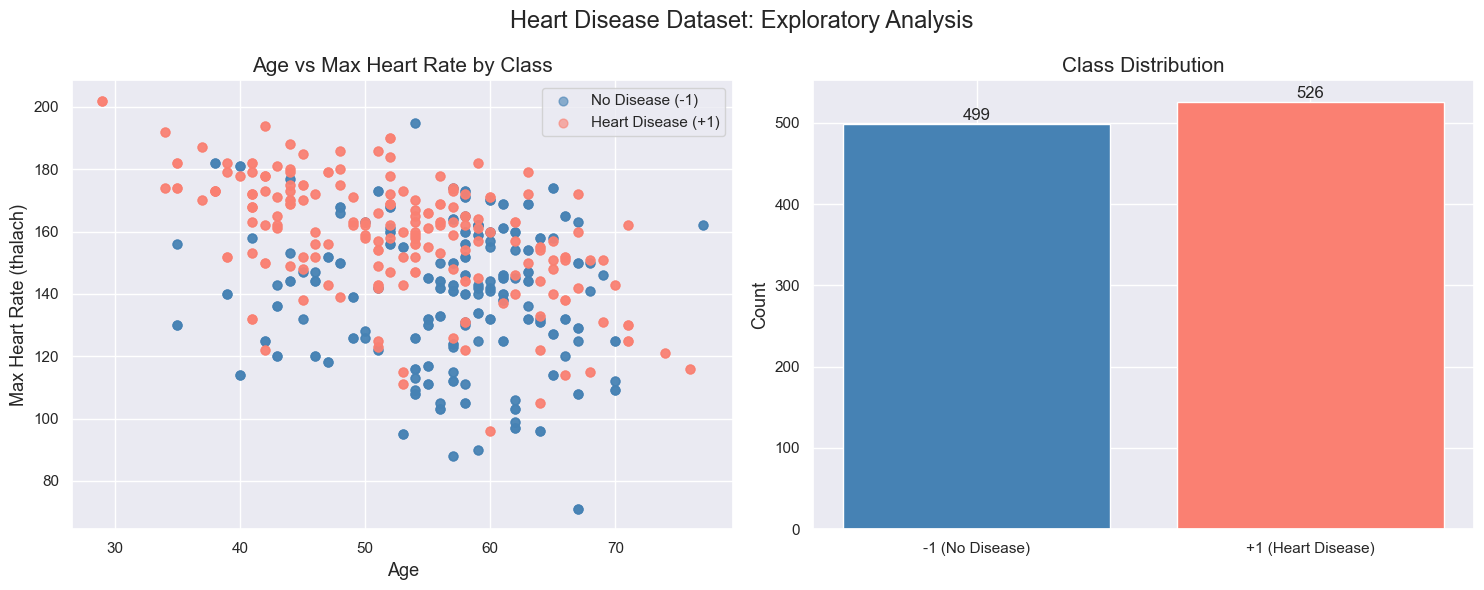

In [3]:
# EDA: Scatter of age vs thalach (max heart rate) colored by class
try:
    age = df['age'].values
    thalach = df['thalach'].values
    labels = y
except NameError:
    age = X[:, 0]
    thalach = X[:, 7]
    labels = y

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: age vs thalach by class
for cls, color, name in [(-1, 'steelblue', 'No Disease (-1)'), (1, 'salmon', 'Heart Disease (+1)')]:
    mask = labels == cls
    axes[0].scatter(age[mask], thalach[mask], c=color, label=name, alpha=0.6, s=40)
axes[0].set_xlabel('Age', fontsize=13)
axes[0].set_ylabel('Max Heart Rate (thalach)', fontsize=13)
axes[0].set_title('Age vs Max Heart Rate by Class', fontsize=15)
axes[0].legend(fontsize=11)

# Class count bar
counts = {'-1 (No Disease)': int((labels == -1).sum()), '+1 (Heart Disease)': int((labels == 1).sum())}
axes[1].bar(counts.keys(), counts.values(), color=['steelblue', 'salmon'], edgecolor='white')
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Class Distribution', fontsize=15)
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=12)

plt.suptitle('Heart Disease Dataset: Exploratory Analysis', fontsize=17)
plt.tight_layout()
plt.show()

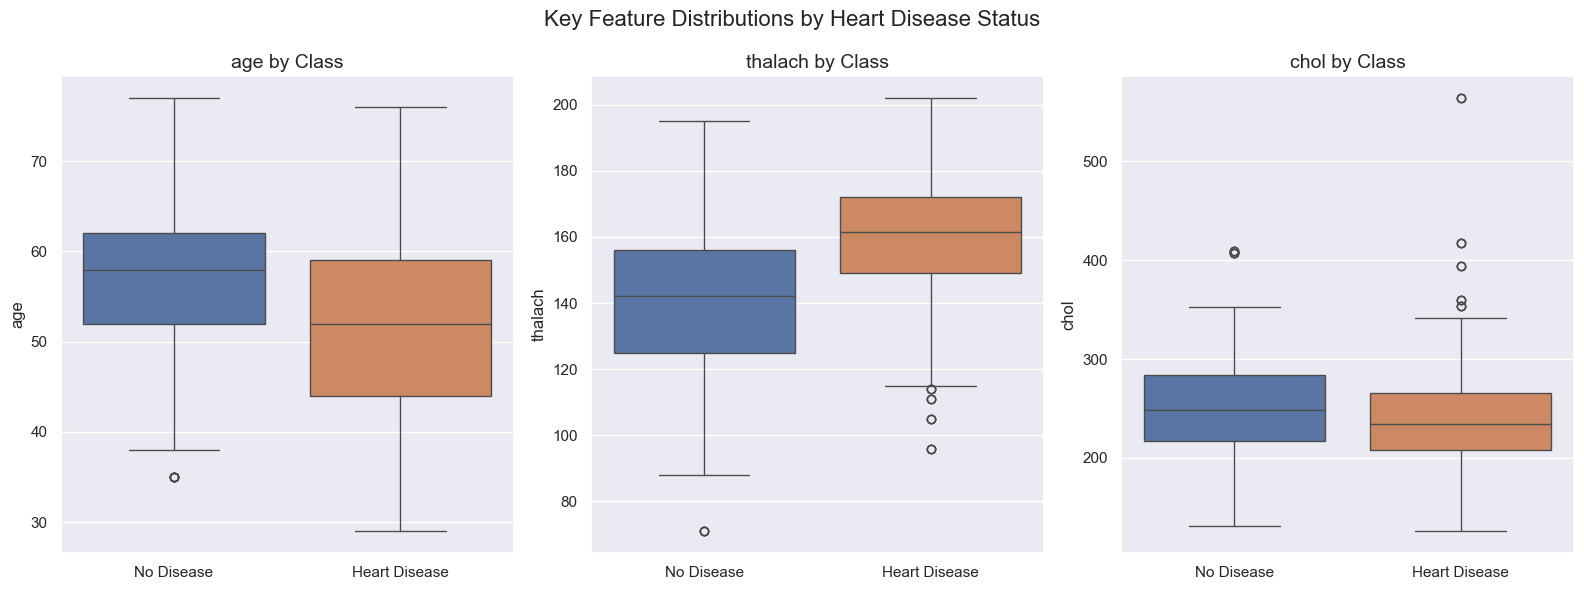

Observations:
  age:     Heart disease patients tend to be slightly older.
  thalach: Patients with heart disease achieve lower max heart rates.
  chol:    Cholesterol distributions overlap substantially between classes.


In [4]:
# EDA: Boxplots of key features split by class
try:
    eda_df = df[['age', 'thalach', 'chol', target_col]].copy()
    eda_df['class'] = np.where(eda_df[target_col] == 0, 'No Disease', 'Heart Disease')
    plot_features = ['age', 'thalach', 'chol']
except Exception:
    eda_df = pd.DataFrame({
        'age': X[:, 0], 'thalach': X[:, 7], 'chol': X[:, 4],
        'class': np.where(y == -1, 'No Disease', 'Heart Disease')
    })
    plot_features = ['age', 'thalach', 'chol']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
palette = {'No Disease': 'steelblue', 'Heart Disease': 'salmon'}

for ax, feat in zip(axes, plot_features):
    sns.boxplot(data=eda_df, x='class', y=feat, ax=ax, hue='class', legend=False)
    ax.set_title(f'{feat} by Class', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel(feat, fontsize=12)

plt.suptitle('Key Feature Distributions by Heart Disease Status', fontsize=16)
plt.tight_layout()
plt.show()

print('Observations:')
print('  age:     Heart disease patients tend to be slightly older.')
print('  thalach: Patients with heart disease achieve lower max heart rates.')
print('  chol:    Cholesterol distributions overlap substantially between classes.')

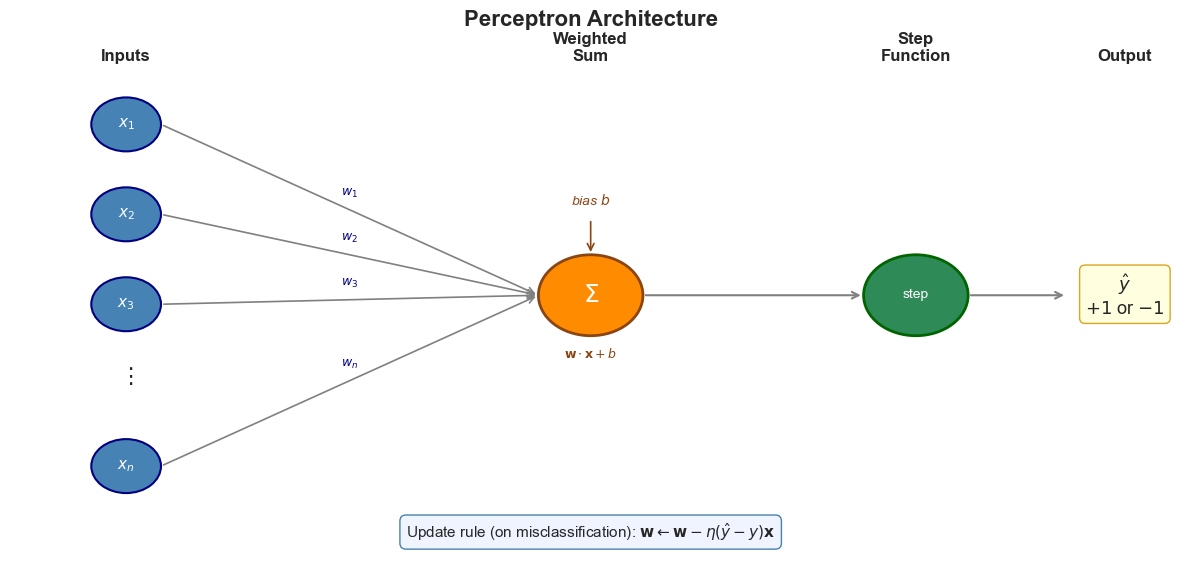

In [5]:
# Diagram: Perceptron architecture
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('white')

# Input nodes
input_labels = ['$x_1$', '$x_2$', '$x_3$', '$\\vdots$', '$x_n$']
input_y = [5.0, 4.0, 3.0, 2.2, 1.2]
for yl, lab in zip(input_y, input_labels):
    if lab == '$\\vdots$':
        ax.text(1.0, yl, lab, ha='center', va='center', fontsize=16)
    else:
        circ = plt.Circle((1.0, yl), 0.3, color='steelblue', ec='navy', lw=1.5, zorder=3)
        ax.add_patch(circ)
        ax.text(1.0, yl, lab, ha='center', va='center', fontsize=11, color='white', zorder=4)

# Weighted sum node
sum_circ = plt.Circle((5.0, 3.1), 0.45, color='darkorange', ec='saddlebrown', lw=2, zorder=3)
ax.add_patch(sum_circ)
ax.text(5.0, 3.1, r'$\Sigma$', ha='center', va='center', fontsize=18, color='white', zorder=4)
ax.text(5.0, 2.45, r'$\mathbf{w}\cdot\mathbf{x}+b$', ha='center', va='center', fontsize=9, color='saddlebrown')

# Step function node
step_circ = plt.Circle((7.8, 3.1), 0.45, color='seagreen', ec='darkgreen', lw=2, zorder=3)
ax.add_patch(step_circ)
ax.text(7.8, 3.1, 'step', ha='center', va='center', fontsize=10, color='white', zorder=4)

# Output
ax.text(9.6, 3.1, '$\\hat{y}$\n$+1$ or $-1$', ha='center', va='center', fontsize=13,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='goldenrod'))

# Arrows from inputs to sum
weight_labels = ['$w_1$', '$w_2$', '$w_3$', '', '$w_n$']
for yl, lab in zip(input_y, weight_labels):
    if lab:
        ax.annotate('', xy=(4.55, 3.1), xytext=(1.3, yl),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
        mx, my = (1.3 + 4.55) / 2, (yl + 3.1) / 2
        ax.text(mx, my + 0.15, lab, ha='center', fontsize=9, color='navy')

# Arrow sum to step
ax.annotate('', xy=(7.35, 3.1), xytext=(5.45, 3.1),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Arrow step to output
ax.annotate('', xy=(9.1, 3.1), xytext=(8.25, 3.1),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Bias label
ax.text(5.0, 4.1, 'bias $b$', ha='center', fontsize=10, color='saddlebrown',
        style='italic')
ax.annotate('', xy=(5.0, 3.55), xytext=(5.0, 3.95),
            arrowprops=dict(arrowstyle='->', color='saddlebrown', lw=1.2))

# Section labels
ax.text(1.0, 5.7, 'Inputs', ha='center', fontsize=12, fontweight='bold')
ax.text(5.0, 5.7, 'Weighted\nSum', ha='center', fontsize=12, fontweight='bold')
ax.text(7.8, 5.7, 'Step\nFunction', ha='center', fontsize=12, fontweight='bold')
ax.text(9.6, 5.7, 'Output', ha='center', fontsize=12, fontweight='bold')

# Update rule annotation
ax.text(5.0, 0.4,
        r'Update rule (on misclassification): $\mathbf{w} \leftarrow \mathbf{w} - \eta(\hat{y} - y)\mathbf{x}$',
        ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', fc='#f0f4ff', ec='steelblue'))

plt.title('Perceptron Architecture', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 820 | Test: 205


## Train the Perceptron

The model iterates over all training samples each epoch, updating weights only for misclassified points.

In [7]:
clf = Perceptron(eta=0.1, epochs=100)
clf.fit(X_train, y_train)

print(f'Epochs run:     {len(clf.errors_)}')
print(f'Final errors:   {clf.errors_[-1] if clf.errors_ else 0}')

Epochs run:     100
Final errors:   163


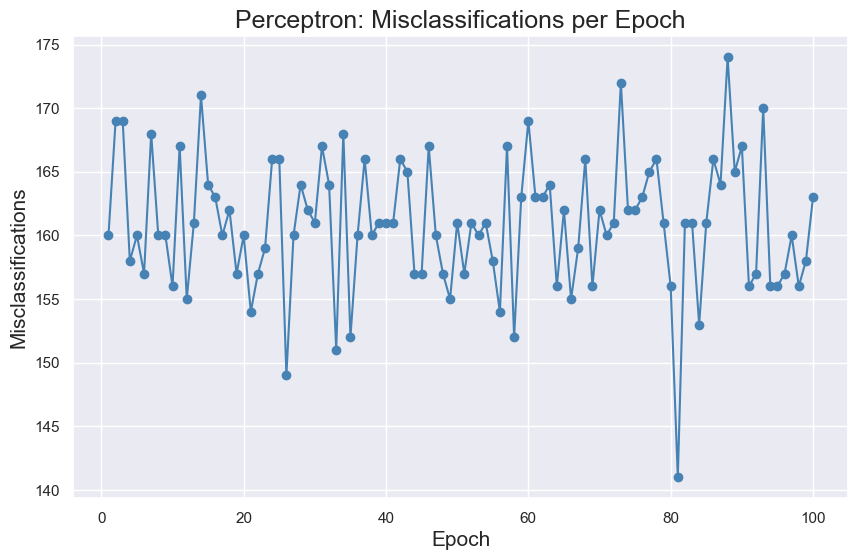

In [8]:
# Plot misclassification count per epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(clf.errors_) + 1), clf.errors_, marker='o', color='steelblue')
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Misclassifications', fontsize=15)
plt.title('Perceptron: Misclassifications per Epoch', fontsize=18)
plt.show()

In [9]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])
print(f'Confusion Matrix:\n{cm}')

Test Accuracy: 0.7366
Confusion Matrix:
[[69 33]
 [21 82]]


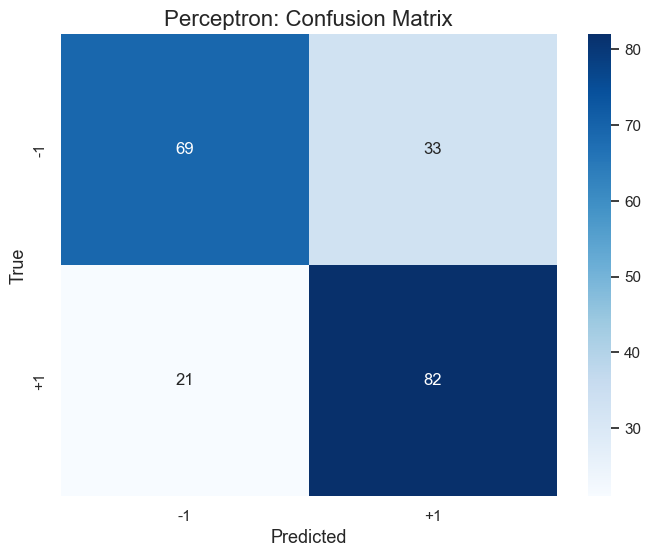

In [10]:
# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['-1', '+1'], yticklabels=['-1', '+1'])
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.title('Perceptron: Confusion Matrix', fontsize=16)
plt.show()

## Interpretation

**Convergence curve:** If the misclassification count reaches zero, the Perceptron found a separating hyperplane and the Convergence Theorem guarantees this happened in finite steps. If the curve plateaus above zero, the data is not linearly separable in the current feature space.

**Confusion matrix:** The off-diagonal entries show the two types of error:
- False positives (predicted heart disease when there is none) raise unnecessary alarm.
- False negatives (missed heart disease cases) are the more dangerous error in a clinical setting.

**Weight vector:** The learned $\mathbf{w}$ defines the separating hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$. Features with large positive weights push the prediction toward $+1$ (heart disease). Features with large negative weights push toward $-1$ (no disease).

**Limitations observed here:** The heart disease dataset has overlapping class distributions (as seen in the EDA boxplots for cholesterol). A Logistic Regression or SVM would likely achieve higher accuracy by finding a margin-maximizing boundary rather than any separating hyperplane.